In [86]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [87]:
data = pd.read_csv("../data/clean/cleaned_data.csv")

In [88]:
data["avg_monthly_charge"] = np.where(
    data["tenure_months"] > 0,
    data["total_charges"] / data["tenure_months"],
    data["monthly_charges"]
)

In [89]:
print(data[
    [
        "customerid",
        "tenure_months",
        "monthly_charges",
        "total_charges",
        "avg_monthly_charge",
        "churn_value"
    ]
].sample(100))

      customerid  tenure_months  monthly_charges  total_charges  \
3511  5242-UOWHD             45            20.35         929.20   
5147  3639-XJHKQ             19            60.60        1297.80   
5303  6509-TSGWN             37            26.45         911.60   
3163  3658-QQJYD             62            74.30        4698.05   
2470  6286-ZHAOK             20            25.55         507.40   
1483  6424-ELEYH              3            74.75         229.50   
4194  9099-FTUHS             23            54.40        1249.25   
6574  2974-GGUXS             36            91.95        3301.05   
4627  5789-LDFXO             24            24.60         592.65   
2926  1666-JZPZT             27            49.00        1291.35   
4431  9402-ORRAH             15            91.50        1400.30   
424   8017-LXHFA             23            94.75        2293.60   
5059  2700-LUEVA              1            20.75          20.75   
6725  2257-BOVXD             14            66.60         979.5

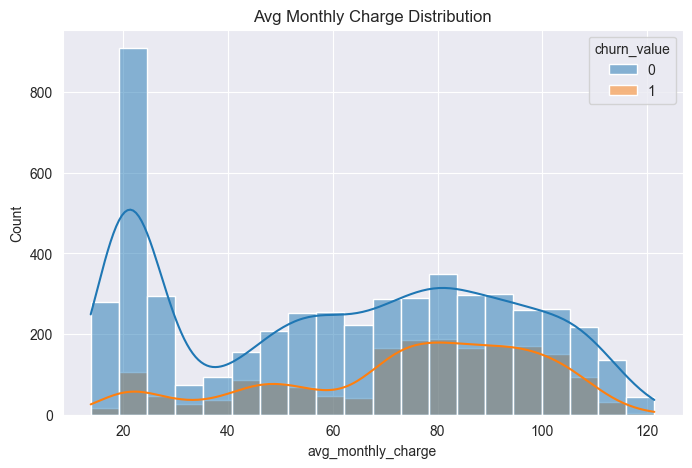

In [90]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=data,
    x="avg_monthly_charge",
    hue="churn_value",
    kde=True
)

plt.title("Avg Monthly Charge Distribution")
plt.show()

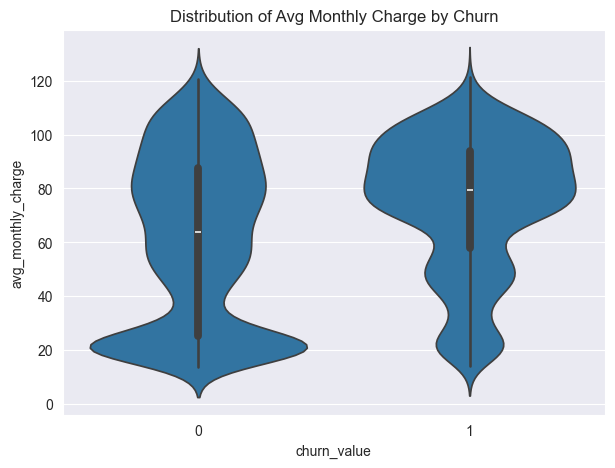

In [91]:
plt.figure(figsize=(7,5))

sns.violinplot(
    x="churn_value",
    y="avg_monthly_charge",
    data=data
)

plt.title("Distribution of Avg Monthly Charge by Churn")
plt.show()

In [92]:
global_avg = data["monthly_charges"].mean()
data["charge_vs_avg"] = data["monthly_charges"] - global_avg

print(data[
    [
        "customerid",
        "monthly_charges",
        "charge_vs_avg",
        "churn_value",
        "churn_reason"
    ]
].sample(100))

      customerid  monthly_charges  charge_vs_avg  churn_value  \
203   6275-YDUVO            86.20      21.438308            1   
4051  5815-HGGHV            64.15      -0.611692            0   
3865  1697-LYYYX            19.10     -45.661692            0   
5850  4067-HLYQI            70.40       5.638308            0   
6170  1480-IVEVR            81.60      16.838308            0   
3875  7883-ROJOC            44.90     -19.861692            0   
5589  9500-LTVBP            80.05      15.288308            0   
1172  2479-BRAMR            83.75      18.988308            1   
6400  0118-JPNOY            85.80      21.038308            0   
2006  5524-KHNJP            74.75       9.988308            0   
6564  2335-GSODA            40.10     -24.661692            0   
2545  4694-PHWFW            19.95     -44.811692            0   
6139  8695-ARGXZ            75.55      10.788308            0   
5113  3373-YZZYM            19.20     -45.561692            0   
4315  2706-QZIHY         

In [93]:
denom = data["tenure_months"] * data["monthly_charges"]
data["payment_ratio"] = np.where(denom > 0, data["total_charges"] / denom, 1.0)

print(data[
    [
        "customerid",
        "tenure_months",
        "monthly_charges",
        "payment_ratio",
        "churn_value",
        "churn_reason"
    ]
].sample(100))

      customerid  tenure_months  monthly_charges  payment_ratio  churn_value  \
1743  4701-AHWMW             55            54.55       0.992684            1   
4321  9659-ZTWSM             66           107.35       0.995321            0   
6746  4816-OKWNX             50           103.40       1.012843            0   
2915  3870-SPZSI             70           113.05       0.994383            0   
659   4277-PVRAN              8            80.10       1.060081            1   
3168  2243-FNMMI             20            19.40       1.070619            0   
6481  2946-KIQSP             35            33.45       1.004356            0   
2528  5170-PTRKA             49            35.80       1.015848            0   
283   4361-BKAXE             41           114.50       0.964416            1   
4022  4139-JPIAM             51            44.45       0.962328            0   
1009  2656-TABEH              4           100.20       1.048403            1   
3773  9153-BTBVV             71         

In [94]:
print(data.groupby("churn_value")["payment_ratio"].describe())

              count      mean       std       min       25%  50%       75%  \
churn_value                                                                  
0            5174.0  1.000642  0.051393  0.689356  0.979169  1.0  1.020237   
1            1869.0  0.999256  0.050351  0.711973  0.981520  1.0  1.016602   

                  max  
churn_value            
0            1.573454  
1            1.356204  


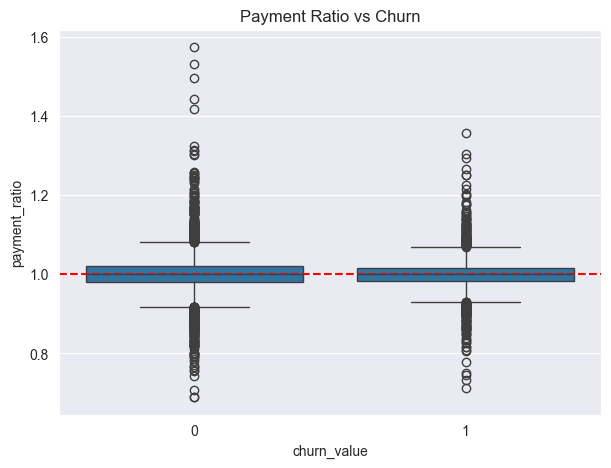

In [95]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="churn_value",
    y="payment_ratio",
    data=data
)

plt.axhline(1, color="red", linestyle="--")

plt.title("Payment Ratio vs Churn")

plt.show()

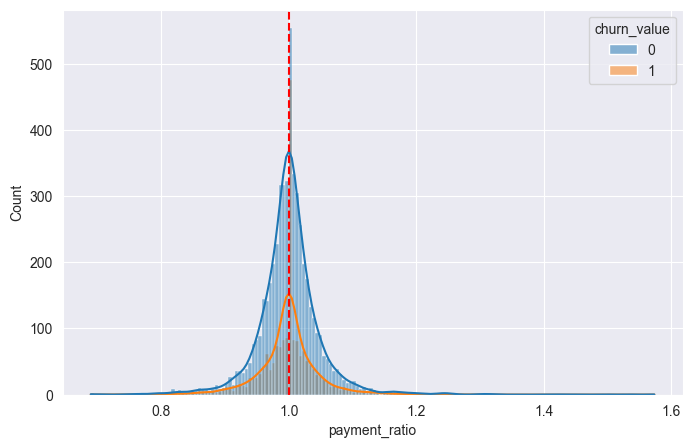

In [96]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=data,
    x="payment_ratio",
    hue="churn_value",
    kde=True
)

plt.axvline(1, color="red", linestyle="--")

plt.show()

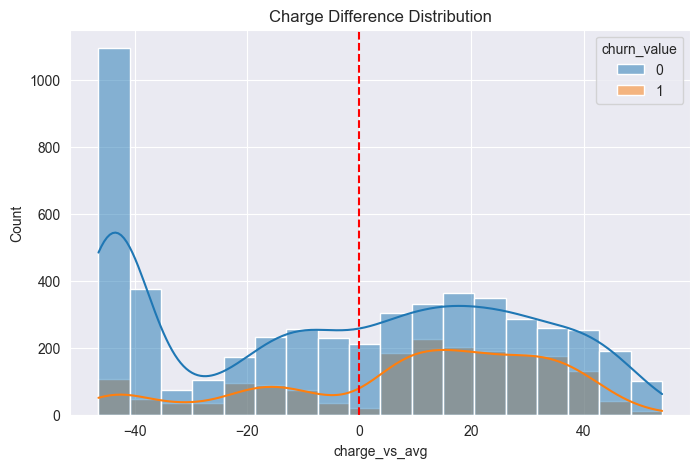

In [97]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=data,
    x="charge_vs_avg",
    hue="churn_value",
    kde=True
)

plt.axvline(0, color="red", linestyle="--")

plt.title("Charge Difference Distribution")
plt.show()

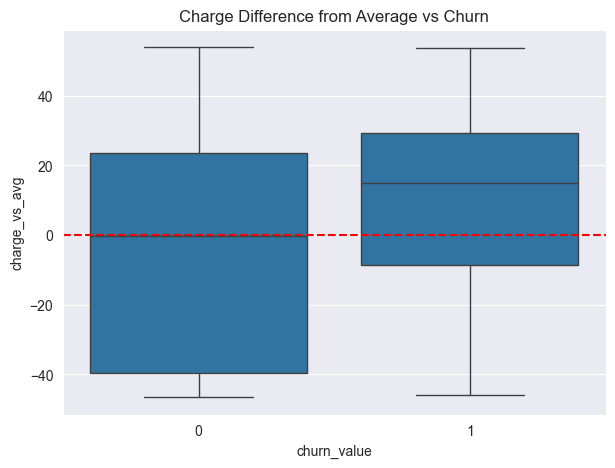

In [98]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="churn_value",
    y="charge_vs_avg",
    data=data
)

plt.title("Charge Difference from Average vs Churn")
plt.axhline(0, color="red", linestyle="--")

plt.show()

In [99]:
service_cols = [
    "phone_service", "online_security", "online_backup",
    "device_protection", "tech_support", "streaming_tv", "streaming_movies"
]

for col in service_cols:
    print(f"{col} \n", data[col].unique())
    print()

phone_service 
 <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

online_security 
 <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

online_backup 
 <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

device_protection 
 <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

tech_support 
 <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

streaming_tv 
 <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

streaming_movies 
 <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str



In [100]:
data["total_services"] = (data[service_cols] == "Yes").sum(axis=1)

print(data[
    [
        "customerid",
        "total_services",
        "churn_value",
        "churn_reason"
    ]
].sample(100))

      customerid  total_services  churn_value  \
6016  4423-JWZJN               3            0   
6003  0816-TSPHQ               1            0   
1425  1597-FZREH               5            1   
6355  4700-UBQMV               4            0   
4182  3181-VTHOE               4            0   
2483  4178-EGMON               4            0   
2413  6549-YMFAW               1            0   
6935  1545-ACTAS               5            0   
4481  2254-DLXRI               2            0   
3828  5609-IMCGG               3            0   
5206  9518-XXBXE               2            0   
3538  3126-WQMGH               1            0   
2008  8167-GJLRN               1            0   
4165  8809-XKHMD               5            0   
3917  3470-OBUET               5            0   
5956  7880-XSOJX               3            0   
2451  7706-DZNKK               1            0   
5513  9842-EFSYY               5            0   
1200  4547-KQRTM               2            1   
829   7410-KTVFV    

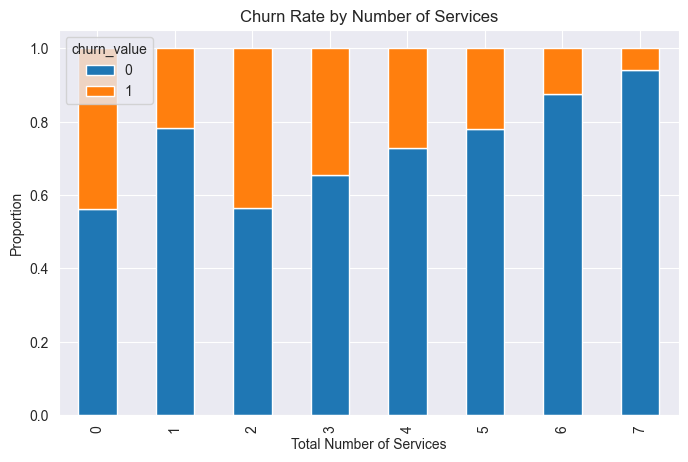

In [101]:
churn_rate = data.groupby("total_services")["churn_value"].value_counts(normalize=True).unstack()

churn_rate.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Churn Rate by Number of Services")
plt.xlabel("Total Number of Services")
plt.ylabel("Proportion")
plt.show()

In [102]:
data["cost_per_service"] = np.where(
    data["total_services"] > 0,
    data["monthly_charges"] / data["total_services"],
    data["monthly_charges"]
)

print(data[
    [
        "customerid",
        "total_services",
        "cost_per_service",
        "churn_value",
        "monthly_charges",
        "churn_reason"
    ]
].sample(100))

      customerid  total_services  cost_per_service  churn_value  \
1958  9560-BBZXK               1         31.050000            0   
532   3074-GQWYX               1         75.900000            1   
172   1448-PWKYE               2         40.000000            1   
1943  9803-FTJCG               4         16.712500            0   
2772  3055-MJDSB               0         24.600000            0   
369   9518-RWHZL               4         25.012500            1   
5704  0786-IVLAW               5         21.620000            0   
6873  6668-CNMFP               3         29.783333            0   
4531  2623-DRYAM               4         25.437500            0   
2788  6507-ZJSUR               3         30.150000            0   
5272  2519-TWKFS               2         27.550000            0   
4042  6176-YJWAS               5         19.590000            0   
5606  6892-BOGQE               1         20.900000            0   
4273  8123-QBNAZ               5         20.900000            

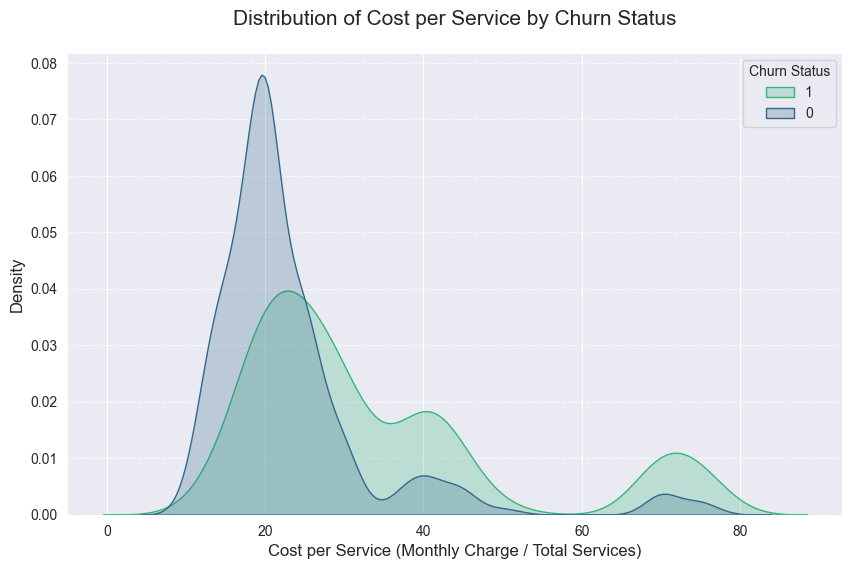

In [103]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=data,
    x="cost_per_service",
    hue="churn_value",
    fill=True,
    common_norm=False,
    palette="viridis"
)

plt.title("Distribution of Cost per Service by Churn Status", fontsize=15, pad=20)
plt.xlabel("Cost per Service (Monthly Charge / Total Services)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(title="Churn Status", labels=["1", "0"])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [104]:
"""data["cost_bin"] = pd.qcut(data["cost_per_service"], 5)

pivot = data.pivot_table(
    values="churn_value",
    index="total_services",
    columns="cost_bin",
    aggfunc="mean"
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Churn Rate by Total Services and Cost per Service")
plt.xlabel("Cost per Service (Binned)")
plt.ylabel("Total Services")
plt.show()"""

'data["cost_bin"] = pd.qcut(data["cost_per_service"], 5)\n\npivot = data.pivot_table(\n    values="churn_value",\n    index="total_services",\n    columns="cost_bin",\n    aggfunc="mean"\n)\n\nplt.figure(figsize=(10,6))\nsns.heatmap(pivot, annot=True, cmap="coolwarm", fmt=".2f")\nplt.title("Churn Rate by Total Services and Cost per Service")\nplt.xlabel("Cost per Service (Binned)")\nplt.ylabel("Total Services")\nplt.show()'

In [105]:
data["high_risk"] = (
    (data["contract"]          == "Month-to-month").astype(int) +
    (data["paperless_billing"] == "Yes").astype(int) +
    (data["payment_method"]    == "Electronic check").astype(int)
)

print(data[
    [
        "customerid",
        "high_risk",
        "churn_value",
        "churn_reason"
    ]
].sample(100))

      customerid  high_risk  churn_value  \
4200  1345-ZUKID          0            0   
6321  0057-QBUQH          2            0   
2923  9046-DQMTP          1            0   
6998  5568-DMXZS          3            0   
460   7279-BUYWN          3            1   
3004  5071-FBJFS          2            0   
578   3988-RQIXO          3            1   
4905  6016-NXBNJ          1            0   
118   2359-KMGLI          3            1   
3117  7359-WWYJV          0            0   
5842  8676-OOQEJ          2            0   
2709  0831-JNISG          0            0   
6739  6437-UDQJM          1            0   
772   5590-BYNII          3            1   
4970  4291-YZODP          0            0   
5510  8180-AKMJV          2            0   
281   3097-NNSPB          2            1   
1940  7233-PAHHL          1            0   
6551  8778-LMWTJ          3            0   
3250  9938-PRCVK          0            0   
882   5519-YLDGW          3            1   
6904  8930-XOTDP          1     

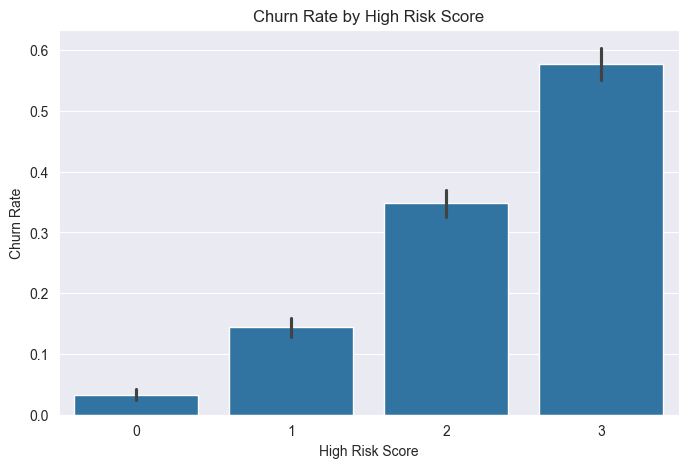

In [106]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="high_risk",
    y="churn_value",
    data=data
)

plt.title("Churn Rate by High Risk Score")
plt.ylabel("Churn Rate")
plt.xlabel("High Risk Score")

plt.show()

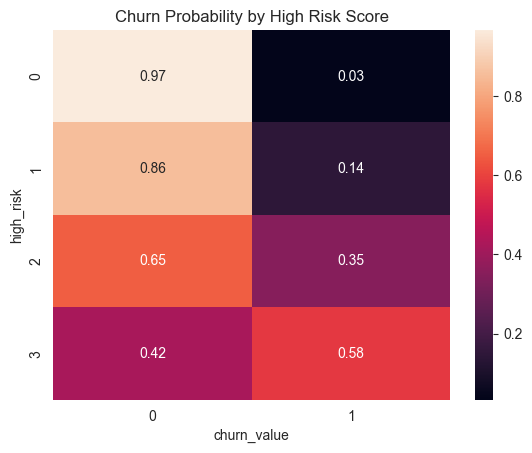

In [107]:
risk_table = pd.crosstab(
    data["high_risk"],
    data["churn_value"],
    normalize="index"
)

sns.heatmap(
    risk_table,
    annot=True,
    fmt=".2f"
)

plt.title("Churn Probability by High Risk Score")
plt.show()

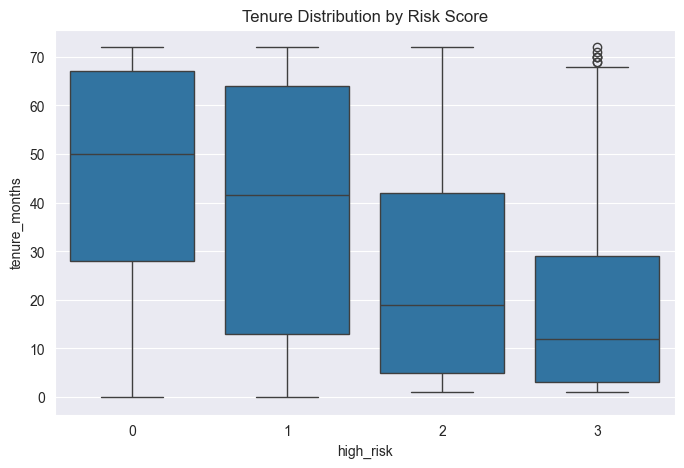

In [108]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="high_risk",
    y="tenure_months",
    data=data
)

plt.title("Tenure Distribution by Risk Score")
plt.show()

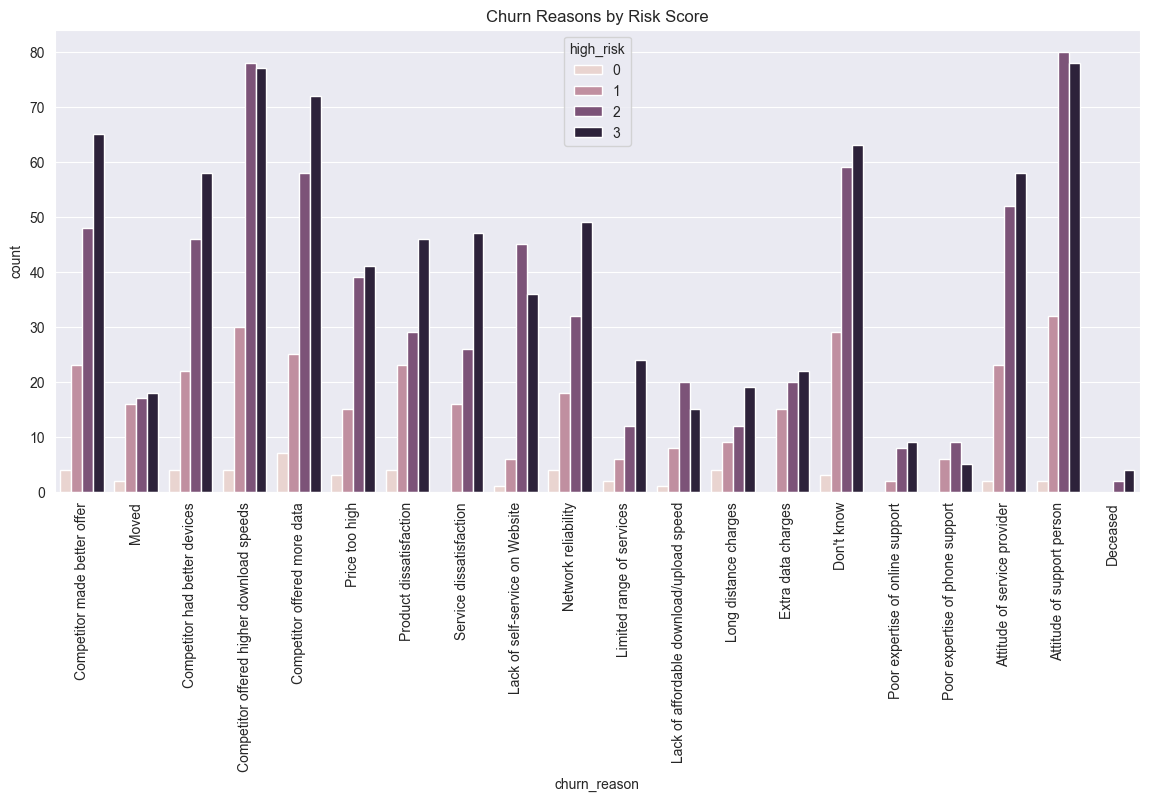

In [109]:
plt.figure(figsize=(14,6))

sns.countplot(
    x="churn_reason",
    hue="high_risk",
    data=data[data["churn_value"] == 1]
)

plt.xticks(rotation=90)
plt.title("Churn Reasons by Risk Score")
plt.show()

In [110]:
contract_score_map = {"Month-to-month": 0, "One year": 1, "Two year": 2}

data["engagement_score"] = (
    (data["partner"]    == "Yes").astype(int) +
    (data["dependents"] == "Yes").astype(int) +
    data["contract"].map(contract_score_map) +
    (data["total_services"] / 7) +
    (data["tenure_months"] / 72)
)

print(data[
    [
        "customerid",
        "engagement_score",
        "churn_value",
        "churn_reason"
    ]
].sample(100))

      customerid  engagement_score  churn_value  \
4057  6898-MDLZW          0.595238            0   
2705  3156-QLHBO          1.170635            0   
2896  8714-CTZJW          0.484127            0   
2614  8917-FAEMR          2.656746            0   
399   7881-EVUAD          0.456349            1   
4675  8573-JGCZW          1.378968            0   
3055  3584-WKTTW          3.565476            0   
3832  3301-LSLWQ          0.831349            0   
3589  9121-PHQSR          1.507937            0   
6801  2027-CWDNU          2.678571            0   
4263  6734-JDTTV          5.045635            0   
3209  0817-HSUSE          0.728175            0   
6758  0827-ITJPH          2.642857            0   
943   1501-SGHBW          0.170635            1   
3336  7710-JSYOA          5.529762            0   
189   3900-AQPHZ          0.156746            1   
2231  7971-HLVXI          5.285714            0   
5918  3703-TTEPD          0.863095            0   
2126  8966-SNIZF          4.115

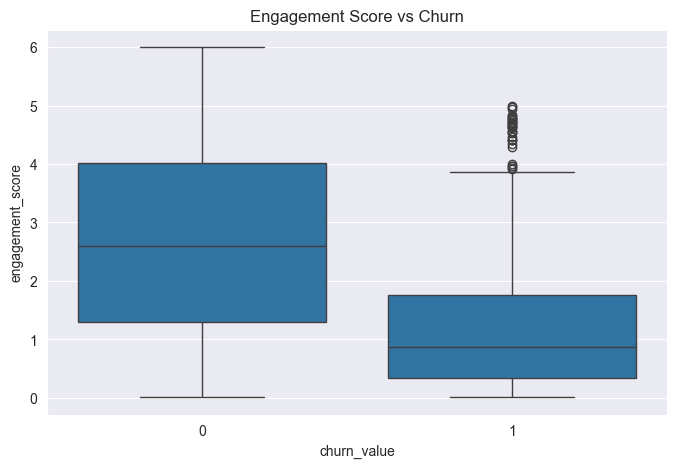

In [111]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="churn_value",
    y="engagement_score",
    data=data
)

plt.title("Engagement Score vs Churn")
plt.show()

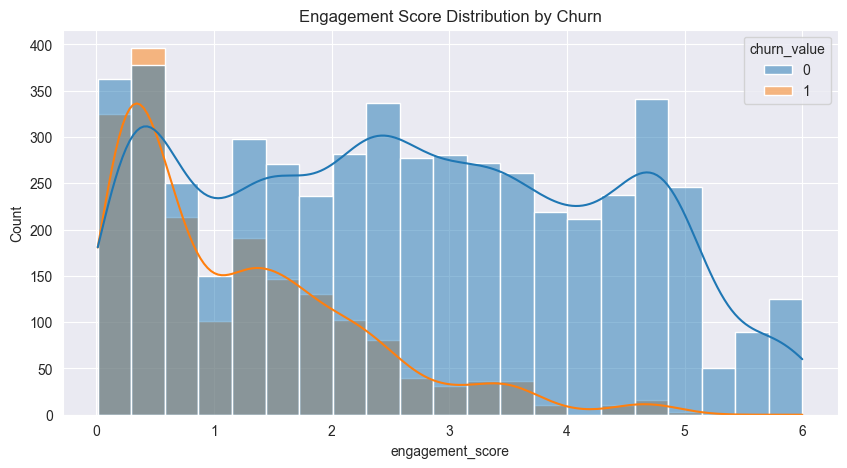

In [112]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=data,
    x="engagement_score",
    hue="churn_value",
    kde=True
)

plt.title("Engagement Score Distribution by Churn")
plt.show()

In [113]:
"""data["engagement_bin"] = pd.cut(
    data["engagement_score"],
    bins=5
)

plt.figure(figsize=(12,5))

sns.barplot(
    x="engagement_bin",
    y="churn_value",
    data=data
)

plt.xticks(rotation=45)
plt.title("Churn Rate by Engagement Score")
plt.show()"""

'data["engagement_bin"] = pd.cut(\n    data["engagement_score"],\n    bins=5\n)\n\nplt.figure(figsize=(12,5))\n\nsns.barplot(\n    x="engagement_bin",\n    y="churn_value",\n    data=data\n)\n\nplt.xticks(rotation=45)\nplt.title("Churn Rate by Engagement Score")\nplt.show()'

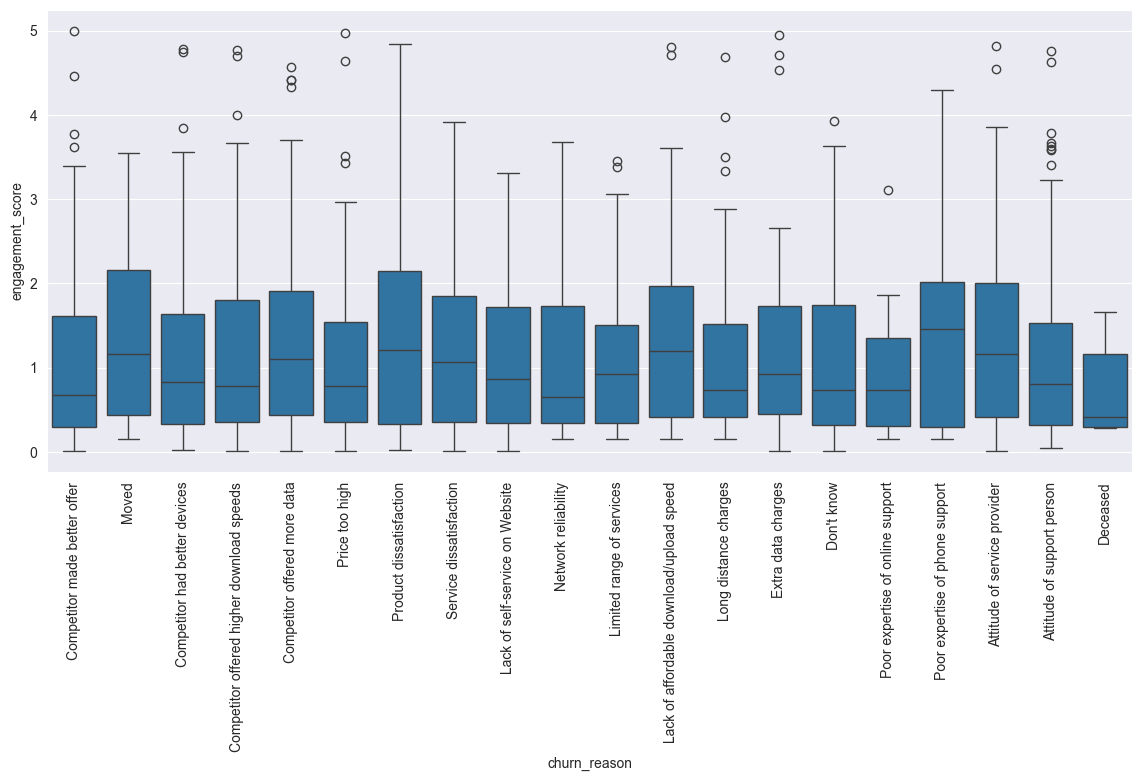

In [114]:
plt.figure(figsize=(14,6))

sns.boxplot(
    x="churn_reason",
    y="engagement_score",
    data=data[data["churn_value"] == 1]
)

plt.xticks(rotation=90)
plt.show()

In [115]:
contract_proxy          = data["contract"].map(contract_score_map)
data["tenure_x_contract"] = data["tenure_months"] * contract_proxy

print(data[
    [
        "customerid",
        "tenure_x_contract",
        "churn_value",
        "churn_reason"
    ]
].sample(100))

      customerid  tenure_x_contract  churn_value  \
3872  5996-DAOQL                  0            0   
6704  2342-CKIAO                  0            0   
1497  3244-DCJWY                  0            1   
1650  7153-OANIO                  0            1   
3093  1219-NNDDO                  0            0   
2417  6621-YOBKI                  0            0   
4863  0374-AACSZ                  0            0   
4159  4429-WYGFR                  0            0   
3311  8735-IJJEG                  0            0   
6301  5025-GOOKI                  0            0   
6715  7426-GSWPO                  0            0   
865   8058-JMEQO                  0            1   
2371  3088-FVYWK                106            0   
394   2667-WYLWJ                  8            1   
4005  2668-TZSPS                  0            0   
2363  8095-WANWK                  0            0   
6645  2911-IJORQ                 37            0   
2937  1735-XMJVH                  0            0   
4569  6878-G

In [116]:
data["charge_x_risk"] = data["monthly_charges"] * data["high_risk"]

print(data[
    [
        "customerid",
        "charge_x_risk",
        "churn_value",
        "churn_reason"
    ]
].sample(100))

      customerid  charge_x_risk  churn_value  \
1762  2810-FTLEM         150.45            1   
4199  2253-KPMNB           0.00            0   
5035  3740-RLMVT          60.95            0   
381   2951-QOQTK          80.80            1   
1212  7817-BOQPW         226.65            1   
5130  0420-TXVSG          66.10            0   
4432  6483-OATDN         102.60            0   
4029  0106-UGRDO         232.00            0   
4116  1406-PUQVY         149.70            0   
2951  9480-BQJEI          92.30            0   
3763  4061-UKJWL          45.45            0   
6664  9332-GYWLO         109.70            0   
113   0880-TKATG         202.30            1   
6365  9812-GHVRI          83.85            0   
2957  6281-FKEWS          98.10            0   
2752  5232-NXPAY           0.00            0   
1026  3886-CERTZ         218.50            1   
3679  1475-VWVDO         224.70            0   
3288  6732-VAILE          85.95            0   
6576  2101-RANCD         219.30         

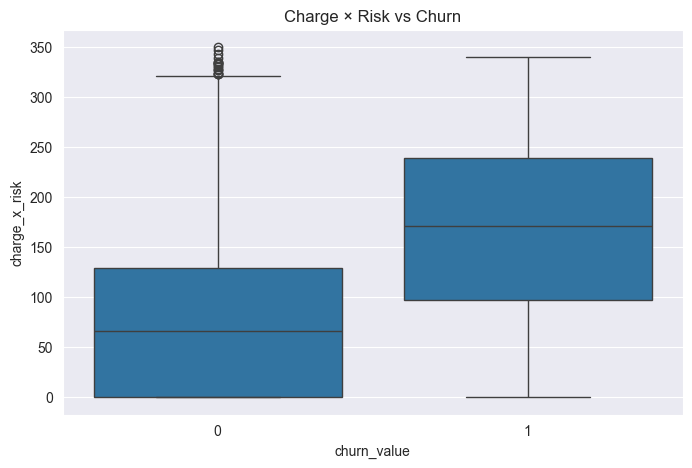

In [117]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="churn_value",
    y="charge_x_risk",
    data=data
)

plt.title("Charge × Risk vs Churn")
plt.show()

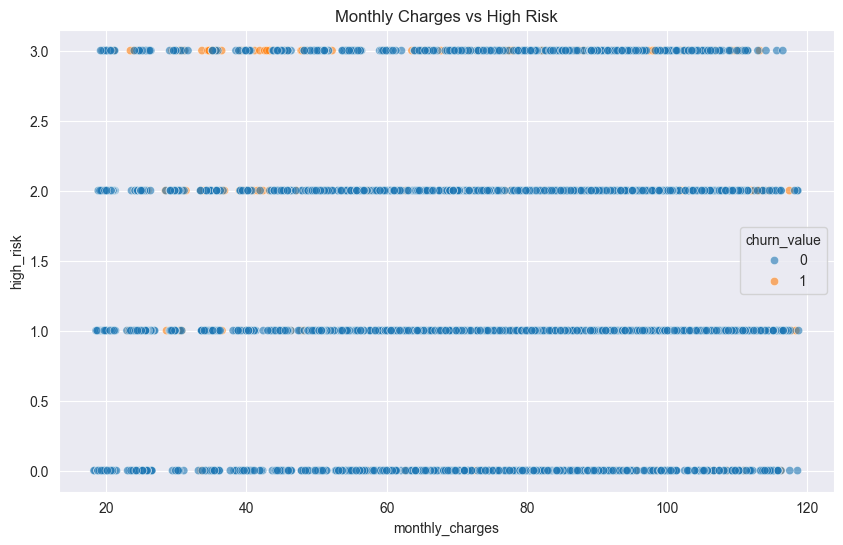

In [118]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="monthly_charges",
    y="high_risk",
    hue="churn_value",
    data=data,
    alpha=0.6
)

plt.title("Monthly Charges vs High Risk")
plt.show()

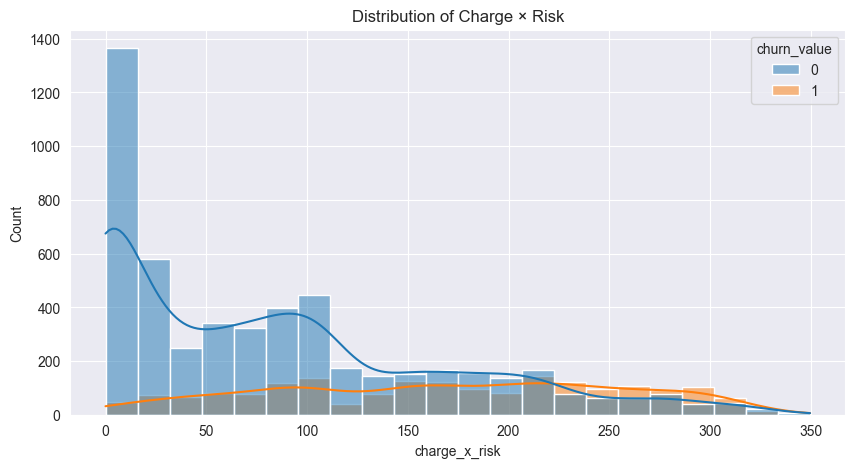

In [119]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=data,
    x="charge_x_risk",
    hue="churn_value",
    kde=True
)

plt.title("Distribution of Charge × Risk")
plt.show()

In [120]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

numeric_cols = [
    "tenure_months",
    "monthly_charges",
    "total_charges"
]

for col in numeric_cols:

    for churn_class in data["churn_value"].unique():

        subset = data[data["churn_value"] == churn_class]

        Q1 = subset[col].quantile(0.25)
        Q3 = subset[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = subset[
            (subset[col] < lower) |
            (subset[col] > upper)
        ]

        print("\n" + "="*60)
        print(f"Column: {col} | Churn: {churn_class}")
        print(f"Outlier Count: {len(outliers)}")
        print("="*60)

        print(
                outliers[
                    [
                        "customerid",
                        col,
                        "monthly_charges",
                        "total_charges",
                    ]
                ]
        )


Column: tenure_months | Churn: 1
Outlier Count: 23
      customerid  tenure_months  monthly_charges  total_charges
202   4853-RULSV             70           104.00        7250.15
248   2834-JRTUA             71           108.05        7532.15
339   0201-OAMXR             70           115.55        8127.60
751   4550-VBOFE             70           102.95        7101.50
793   7317-GGVPB             71           108.60        7690.90
815   8809-RIHDD             72           103.40        7372.65
901   0917-EZOLA             72           104.15        7689.95
916   0748-RDGGM             70           109.50        7534.65
1026  3886-CERTZ             72           109.25        8109.80
1091  6559-ILWKJ             71            49.35        3515.25
1182  8580-QVLOC             72            92.45        6440.25
1206  2889-FPWRM             72           117.80        8684.80
1429  3512-IZIKN             70            65.30        4759.75
1467  2225-ZRGSG             70            93.90    

In [121]:
data.groupby("tenure_months")["churn_value"].mean()

tenure_months
0     0.000000
1     0.619902
2     0.516807
3     0.470000
4     0.471591
5     0.481203
6     0.363636
7     0.389313
8     0.341463
9     0.386555
10    0.387931
11    0.313131
12    0.324786
13    0.348624
14    0.315789
15    0.373737
16    0.350000
17    0.298851
18    0.247423
19    0.260274
20    0.253521
21    0.269841
22    0.300000
23    0.152941
24    0.244681
25    0.291139
26    0.189873
27    0.180556
28    0.210526
29    0.208333
30    0.222222
31    0.246154
32    0.275362
33    0.218750
34    0.184615
35    0.170455
36    0.200000
37    0.230769
38    0.220339
39    0.250000
40    0.203125
41    0.200000
42    0.215385
43    0.230769
44    0.117647
45    0.098361
46    0.162162
47    0.205882
48    0.140625
49    0.227273
50    0.147059
51    0.117647
52    0.100000
53    0.200000
54    0.191176
55    0.140625
56    0.125000
57    0.123077
58    0.164179
59    0.133333
60    0.078947
61    0.105263
62    0.071429
63    0.055556
64    0.050000
65    0.118

In [122]:
data.columns

Index(['customerid', 'city', 'zip_code', 'latitude', 'longitude', 'gender',
       'senior_citizen', 'partner', 'dependents', 'tenure_months',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn_value',
       'churn_score', 'cltv', 'churn_reason', 'avg_monthly_charge',
       'charge_vs_avg', 'payment_ratio', 'total_services', 'cost_per_service',
       'high_risk', 'engagement_score', 'tenure_x_contract', 'charge_x_risk'],
      dtype='str')

In [123]:
data.to_parquet("../data/clean/cleaned_featureng_data.parquet", index=False)
data.to_csv("../data/clean/cleaned_featureng_data.csv", index=False)